# Project 1: Simulation and estimation in a Markov model of breast cancer

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.linalg import expm

np.random.seed(42)

# Transition probability matrix (discrete-time)
P = np.array([
    [0.9915, 0.005,  0.0025, 0,     0.001],
    [0,      0.986,  0.005,  0.004, 0.005],
    [0,      0,      0.992,  0.003, 0.005],
    [0,      0,      0,      0.991, 0.009],
    [0,      0,      0,      0,     1.0  ]
])

# Quick sanity check, rows must sum to 1
print("Row sums:", P.sum(axis=1))

Row sums: [1. 1. 1. 1. 1.]


## Part 1:  A discrete-time model 

In [3]:
#Simulate 1000 women until death (state 5, index 4)
def simulate_women(P, n=1000, start_state=0):
    """
    Simulate n women through the Markov chain until death (state index 4).
    Returns:
        lifetimes: array of months until death
        trajectories: list of state sequences
    """
    states = list(range(P.shape[0]))
    lifetimes = []
    trajectories = []

    for _ in range(n):
        state = start_state
        path = [state]
        t = 0
        while state != 4:  # state 4 = death
            state = np.random.choice(states, p=P[state])
            t += 1
            path.append(state)
        lifetimes.append(t)
        trajectories.append(path)

    return np.array(lifetimes), trajectories

lifetimes, trajectories = simulate_women(P, n=1000)

print(f"Mean lifetime:   {lifetimes.mean():.1f} months  ({lifetimes.mean()/12:.1f} years)")
print(f"Median lifetime: {np.median(lifetimes):.1f} months")
print(f"Std deviation:   {lifetimes.std():.1f} months")
print(f"Min / Max:       {lifetimes.min()} / {lifetimes.max()} months")

Mean lifetime:   265.0 months  (22.1 years)
Median lifetime: 224.0 months
Std deviation:   184.4 months
Min / Max:       1 / 1151 months


### Task 1: Lifetime distribution histogram

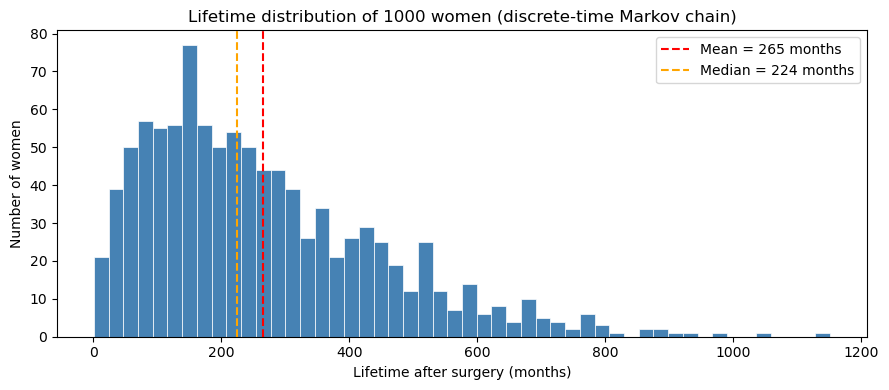

Proportion with local recurrence: 0.589 (589/1000 women)


In [4]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(lifetimes, bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
ax.axvline(lifetimes.mean(),   color='red',    linestyle='--', label=f'Mean = {lifetimes.mean():.0f} months')
ax.axvline(np.median(lifetimes), color='orange', linestyle='--', label=f'Median = {np.median(lifetimes):.0f} months')

ax.set_xlabel('Lifetime after surgery (months)')
ax.set_ylabel('Number of women')
ax.set_title('Lifetime distribution of 1000 women (discrete-time Markov chain)')
ax.legend()
plt.tight_layout()
plt.show()

# Also answer: proportion who ever entered local recurrence (state 1, index 1)
local_recurrence = sum(1 for path in trajectories if 1 in path[1:])
print(f"Proportion with local recurrence: {local_recurrence/1000:.3f} ({local_recurrence}/1000 women)")

- The distribution is right-skewed. Long tail of women who survive many years.
- 58.9% of women eventually experienced local recurrence

### Task 2: State distribution at t=120 months

In [5]:
t = 120

# --- Theoretical distribution: p_t = p0 @ P^t ---
p0 = np.array([1, 0, 0, 0, 0])  # all women start in state 1
Pt = np.linalg.matrix_power(P, t)
p_theoretical = p0 @ Pt
print("Theoretical state distribution at t=120:")
for i, p in enumerate(p_theoretical):
    print(f"  State {i+1}: {p:.6f}")

# --- Empirical: count where each woman is at month 120 ---
state_at_120 = np.zeros(5, dtype=int)
for path in trajectories:
    if len(path) > t:
        state_at_120[path[t]] += 1
    else:
        state_at_120[4] += 1  # already dead

print(f"\nEmpirical state counts at t=120: {state_at_120}")
print(f"Empirical proportions:          {state_at_120/1000}")

# --- Chi-square test ---
expected = p_theoretical * 1000
# Only include states with expected count > 0
mask = expected > 0
chi2, p_value = stats.chisquare(f_obs=state_at_120[mask], f_exp=expected[mask])
print(f"\nChi-square statistic: {chi2:.4f}")
print(f"P-value:              {p_value:.4f}")
print(f"Conclusion: {'Consistent with theory (fail to reject H0)' if p_value > 0.05 else 'Inconsistent with theory (reject H0)'}")

Theoretical state distribution at t=120:
  State 1: 0.359026
  State 2: 0.158956
  State 3: 0.166087
  State 4: 0.067741
  State 5: 0.248189

Empirical state counts at t=120: [364 165 167  69 235]
Empirical proportions:          [0.364 0.165 0.167 0.069 0.235]

Chi-square statistic: 1.0280
P-value:              0.9055
Conclusion: Consistent with theory (fail to reject H0)


The empirical proportions are extremely close to the theoretical ones, and the p-value of 0.91 is very high so we have no reason to reject H0. 

The simulation is behaving as the math predicts.

### Task 3: Compare simulated lifetimes to phase-type distribution

Theoretical mean lifetime: 262.37 months (21.86 years)
Simulated  mean lifetime:  265.04 months (22.09 years)

KS statistic: 0.0236
P-value:      0.6257
Conclusion: Consistent with phase-type distribution (fail to reject H0)


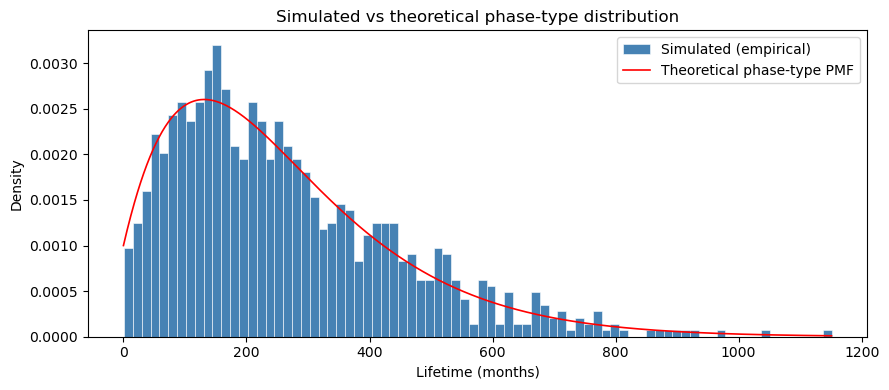

In [6]:
# Ps = sub-matrix of P (remove last row and column)
Ps = P[:4, :4]

# ps = probability of dying from each transient state (last column, first 4 rows)
ps = P[:4, 4]

# pi = initial distribution over transient states
pi = np.array([1, 0, 0, 0])

# Theoretical PMF: P(T=t) = pi @ Ps^t @ ps
max_t = int(lifetimes.max()) + 1
pmf_theoretical = np.zeros(max_t)
for t in range(max_t):
    Ps_t = np.linalg.matrix_power(Ps, t)
    pmf_theoretical[t] = pi @ Ps_t @ ps

# Theoretical mean: E(T) = pi @ (I - Ps)^{-1} @ 1
I = np.eye(4)
mean_theoretical = pi @ np.linalg.inv(I - Ps) @ np.ones(4)
print(f"Theoretical mean lifetime: {mean_theoretical:.2f} months ({mean_theoretical/12:.2f} years)")
print(f"Simulated  mean lifetime:  {lifetimes.mean():.2f} months ({lifetimes.mean()/12:.2f} years)")

# KS test: compare simulated lifetimes to theoretical CDF
cdf_theoretical = np.cumsum(pmf_theoretical)
cdf_at_simulated = cdf_theoretical[lifetimes]  # CDF value at each simulated lifetime

ks_stat, p_value = stats.kstest(lifetimes, lambda t: cdf_theoretical[np.minimum(t.astype(int), max_t-1)])
print(f"\nKS statistic: {ks_stat:.4f}")
print(f"P-value:      {p_value:.4f}")
print(f"Conclusion: {'Consistent with phase-type distribution (fail to reject H0)' if p_value > 0.05 else 'Inconsistent (reject H0)'}")

# Plot: empirical vs theoretical PMF
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(lifetimes, bins=80, density=True, color='steelblue', edgecolor='white',
        linewidth=0.4, label='Simulated (empirical)')
ax.plot(range(max_t), pmf_theoretical, color='red', linewidth=1.2,
        label='Theoretical phase-type PMF')
ax.set_xlabel('Lifetime (months)')
ax.set_ylabel('Density')
ax.set_title('Simulated vs theoretical phase-type distribution')
ax.legend()
plt.tight_layout()
plt.show()

### Task 4: Rejection sampling for conditional expected lifetime

In [7]:

def simulate_one_woman(P):
    """Simulate a single woman, return (lifetime, path)."""
    states = list(range(5))
    state = 0
    path = [state]
    t = 0
    while state != 4:
        state = np.random.choice(states, p=P[state])
        t += 1
        path.append(state)
    return t, path

def condition_met(path):
    """
    Returns True if:
    - Woman survives first 12 months (death not in path[:13])
    - Cancer reappeared locally (state 1) OR distantly (state 2 or 3)
      within first 12 months
    """
    first_12 = path[:13]  # indices 0..12 = months 0..12
    # Must survive 12 months
    if 4 in first_12:
        return False
    # Cancer must have reappeared: state 1 (local), 2 (distant), or 3 (both)
    recurrence_states = {1, 2, 3}
    if not any(s in recurrence_states for s in first_12):
        return False
    return True

# Rejection sampling until 1000 valid simulations
accepted_lifetimes = []
total_simulated = 0

while len(accepted_lifetimes) < 1000:
    t, path = simulate_one_woman(P)
    total_simulated += 1
    if condition_met(path):
        accepted_lifetimes.append(t)

accepted_lifetimes = np.array(accepted_lifetimes)

print(f"Total simulated:       {total_simulated}")
print(f"Accepted:              {len(accepted_lifetimes)}")
print(f"Acceptance rate:       {1000/total_simulated:.4f}")
print(f"\nEstimated E[T | condition]: {accepted_lifetimes.mean():.2f} months "
      f"({accepted_lifetimes.mean()/12:.2f} years)")

# 95% confidence interval
se = accepted_lifetimes.std() / np.sqrt(1000)
ci_low  = accepted_lifetimes.mean() - 1.96 * se
ci_high = accepted_lifetimes.mean() + 1.96 * se
print(f"95% CI: [{ci_low:.2f}, {ci_high:.2f}] months")

Total simulated:       12797
Accepted:              1000
Acceptance rate:       0.0781

Estimated E[T | condition]: 178.03 months (14.84 years)
95% CI: [168.62, 187.44] months


### Task 5: Control variates variance reduction

In [8]:
# Theoretical mean lifetime (known from Task 3)
mu_known = 262.37  # E[T] from phase-type formula

n_women   = 200   # women per batch
n_batches = 100   # repetitions
threshold = 350   # months

crude_estimates = []
cv_estimates    = []

for _ in range(n_batches):
    batch_lifetimes = []
    for _ in range(n_women):
        t, _ = simulate_one_woman(P)
        batch_lifetimes.append(t)
    batch_lifetimes = np.array(batch_lifetimes)

    # Crude Monte Carlo estimate: fraction dying within 350 months
    Y = (batch_lifetimes <= threshold).mean()
    crude_estimates.append(Y)

    # Control variate: sample mean lifetime (correlated with Y)
    Z = batch_lifetimes.mean()
    cv_estimates.append((Y, Z))

crude_estimates = np.array(crude_estimates)
Y_vals = np.array([x[0] for x in cv_estimates])
Z_vals = np.array([x[1] for x in cv_estimates])

# Optimal c: c* = -Cov(Y, Z) / Var(Z)
cov_YZ = np.cov(Y_vals, Z_vals)[0, 1]
var_Z  = np.var(Z_vals, ddof=1)
c_star = -cov_YZ / var_Z
print(f"Optimal c*: {c_star:.6f}")

# Control variate estimator: Y_cv = Y + c*(Z - mu)
cv_corrected = Y_vals + c_star * (Z_vals - mu_known)

# Compare variances
var_crude = np.var(crude_estimates, ddof=1)
var_cv    = np.var(cv_corrected,    ddof=1)
reduction = var_crude / var_cv

print(f"\nCrude MC estimate (mean):  {crude_estimates.mean():.4f}")
print(f"CV estimate (mean):        {cv_corrected.mean():.4f}")
print(f"\nVariance (crude MC): {var_crude:.6f}")
print(f"Variance (CV):       {var_cv:.6f}")
print(f"Variance reduction factor: {reduction:.2f}x")

Optimal c*: 0.001954

Crude MC estimate (mean):  0.7362
CV estimate (mean):        0.7364

Variance (crude MC): 0.001043
Variance (CV):       0.000276
Variance reduction factor: 3.77x


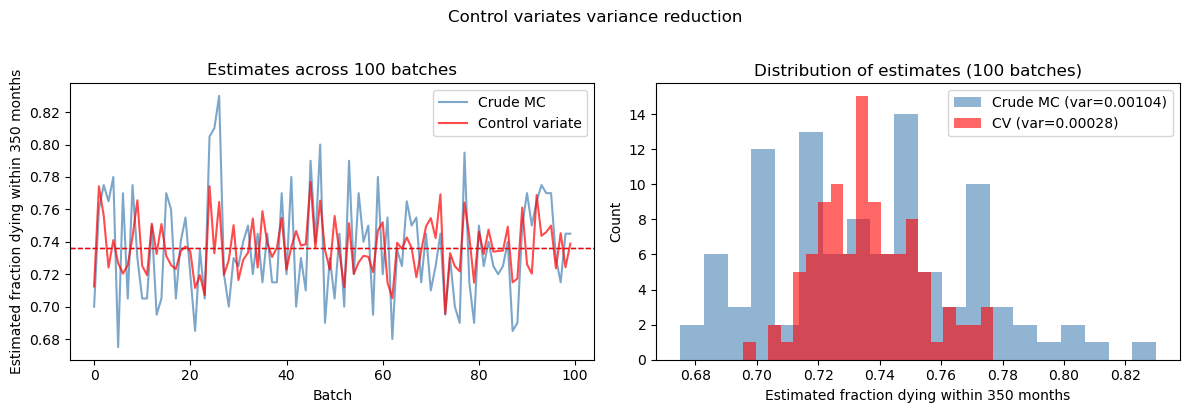

In [9]:
#Plot crude MC vs control variate estimates
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: estimates across 100 batches
axes[0].plot(crude_estimates, color='steelblue', alpha=0.7, label='Crude MC')
axes[0].plot(cv_corrected, color='red', alpha=0.7, label='Control variate')
axes[0].axhline(crude_estimates.mean(), color='steelblue', linestyle='--', linewidth=1)
axes[0].axhline(cv_corrected.mean(), color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Batch')
axes[0].set_ylabel('Estimated fraction dying within 350 months')
axes[0].set_title('Estimates across 100 batches')
axes[0].legend()

# Right: distribution of estimates
axes[1].hist(crude_estimates, bins=20, alpha=0.6, color='steelblue', label=f'Crude MC (var={var_crude:.5f})')
axes[1].hist(cv_corrected,   bins=20, alpha=0.6, color='red',       label=f'CV (var={var_cv:.5f})')
axes[1].set_xlabel('Estimated fraction dying within 350 months')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of estimates (100 batches)')
axes[1].legend()

plt.suptitle('Control variates variance reduction', y=1.02)
plt.tight_layout()
plt.show()

In [10]:
# Continuous-time transition-rate matrix
Q = np.array([
    [-0.0085, 0.005,  0.0025, 0,      0.001],
    [0,       -0.014, 0.005,  0.004,  0.005],
    [0,       0,      -0.008, 0.003,  0.005],
    [0,       0,      0,      -0.009, 0.009],
    [0,       0,      0,      0,      0    ]
])

def simulate_woman_ctmc(Q, start_state=0):
    """
    Simulate one woman through the CTMC until death (state index 4).
    Returns:
        death_time: total time until death (in months)
        path: list of (time, state) tuples marking each transition
    """
    state = start_state
    t = 0.0
    path = [(t, state)]

    while state != 4:
        rate = -Q[state, state]  # total rate out of current state
        sojourn = np.random.exponential(1 / rate)  # time spent in this state
        t += sojourn

        # Jump probabilities: q_ij / rate for all j != state
        jump_probs = Q[state].copy()
        jump_probs[state] = 0
        jump_probs = jump_probs / rate

        state = np.random.choice(range(5), p=jump_probs)
        path.append((t, state))

    return t, path

def state_at_time(path, query_t):
    """Given a path of (time, state) tuples, find which state the woman is in at query_t."""
    state = path[0][1]
    for (t, s) in path:
        if t > query_t:
            break
        state = s
    return state

### Task 7


Mean lifetime: 265.89 months, 95% CI: (253.71, 278.06)
Std deviation: 196.45 months, 95% CI: (188.20, 205.46)


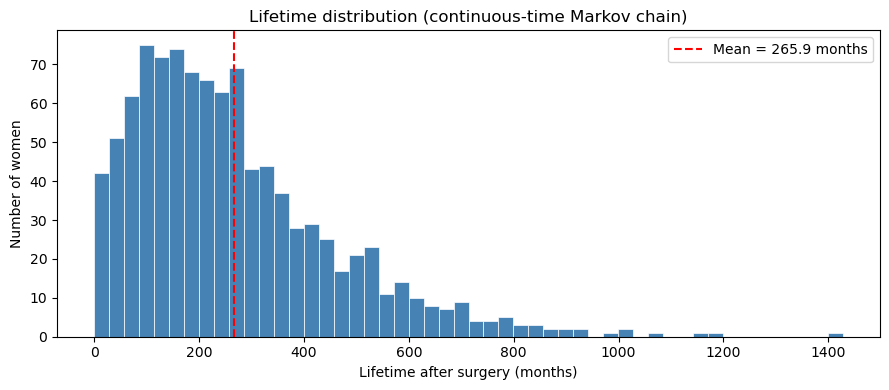


Proportion with distant metastasis present at t=30.5: 0.071


In [11]:
# Simulate 1000 women under the continuous-time model
n = 1000
death_times = []
paths = []

for _ in range(n):
    t, path = simulate_woman_ctmc(Q)
    death_times.append(t)
    paths.append(path)

death_times = np.array(death_times)

# Summary statistics
mean_t = death_times.mean()
std_t  = death_times.std(ddof=1)

# 95% CI for the mean (normal approximation, n=1000 is large)
se_mean = std_t / np.sqrt(n)
ci_mean = (mean_t - 1.96 * se_mean, mean_t + 1.96 * se_mean)

# 95% CI for the std deviation (chi-square based)
from scipy.stats import chi2
chi2_lower = chi2.ppf(0.975, df=n-1)
chi2_upper = chi2.ppf(0.025, df=n-1)
ci_std = (
    np.sqrt((n-1) * std_t**2 / chi2_lower),
    np.sqrt((n-1) * std_t**2 / chi2_upper)
)

print(f"Mean lifetime: {mean_t:.2f} months, 95% CI: ({ci_mean[0]:.2f}, {ci_mean[1]:.2f})")
print(f"Std deviation: {std_t:.2f} months, 95% CI: ({ci_std[0]:.2f}, {ci_std[1]:.2f})")

# Histogram
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(death_times, bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
ax.axvline(mean_t, color='red', linestyle='--', label=f'Mean = {mean_t:.1f} months')
ax.set_xlabel('Lifetime after surgery (months)')
ax.set_ylabel('Number of women')
ax.set_title('Lifetime distribution (continuous-time Markov chain)')
ax.legend()
plt.tight_layout()
plt.show()

# Proportion with distant metastasis present at t = 30.5 months
# "Distant" means state 3 (distant only) OR state 4 (both), 0-indexed: 2 or 3
states_at_305 = [state_at_time(p, 30.5) for p in paths]
distant_count = sum(1 for s in states_at_305 if s in (2, 3))
print(f"\nProportion with distant metastasis present at t=30.5: {distant_count/n:.3f}")

### Task 8

KS statistic: 0.0159
P-value:      0.9585
Conclusion: Consistent with phase-type distribution (fail to reject H0)


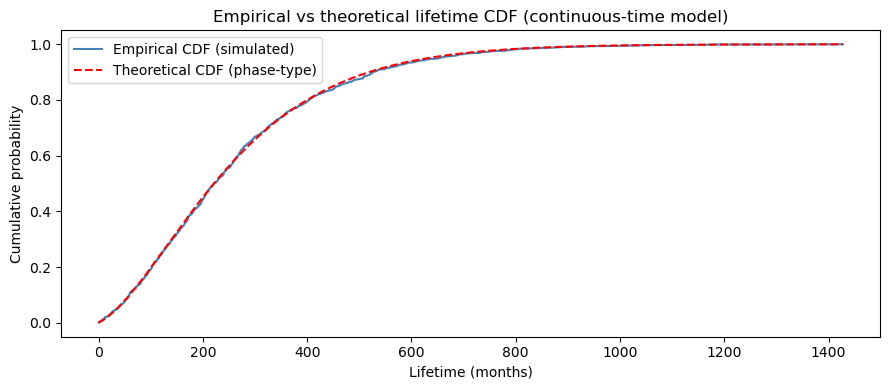

In [12]:
# Theoretical CDF: F_T(t) = 1 - p0 @ expm(Qs * t) @ 1
Qs = Q[:4, :4]   # sub-matrix: remove last row/column (death state)
p0 = np.array([1, 0, 0, 0])   # everyone starts in state 1
ones_vec = np.ones(4)

def theoretical_cdf(t):
    """Theoretical CDF of lifetime at a single time t, via matrix exponential."""
    return 1 - p0 @ expm(Qs * t) @ ones_vec

def theoretical_cdf_vec(t_array):
    """Vectorized version for use with scipy's kstest."""
    return np.array([theoretical_cdf(t) for t in t_array])

# KS test: compares empirical distribution of death_times to theoretical_cdf_vec
ks_stat, p_value = stats.kstest(death_times, theoretical_cdf_vec)

print(f"KS statistic: {ks_stat:.4f}")
print(f"P-value:      {p_value:.4f}")
print(f"Conclusion: {'Consistent with phase-type distribution (fail to reject H0)' if p_value > 0.05 else 'Inconsistent (reject H0)'}")

# Plot: empirical CDF vs theoretical CDF
t_grid = np.linspace(0, death_times.max(), 300)
cdf_theoretical_grid = theoretical_cdf_vec(t_grid)

sorted_times = np.sort(death_times)
ecdf = np.arange(1, n + 1) / n

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sorted_times, ecdf, color='steelblue', label='Empirical CDF (simulated)', linewidth=1.5)
ax.plot(t_grid, cdf_theoretical_grid, color='red', linestyle='--', label='Theoretical CDF (phase-type)', linewidth=1.5)
ax.set_xlabel('Lifetime (months)')
ax.set_ylabel('Cumulative probability')
ax.set_title('Empirical vs theoretical lifetime CDF (continuous-time model)')
ax.legend()
plt.tight_layout()
plt.show()

### Task 9

In [18]:
# Treatment transition-rate matrix
# Diagonal entries computed via eq. (1): q_ii = -(sum of off-diagonal entries in row i)

Q_treatment = np.array([
    [-0.00475, 0.0025, 0.00125, 0,      0.001],
    [0,        -0.007, 0,       0.002,  0.005],
    [0,        0,      -0.008,  0.003,  0.005],
    [0,        0,      0,       -0.009, 0.009],
    [0,        0,      0,       0,      0    ]
])

print("Row sums:", Q_treatment.sum(axis=1))  


Row sums: [2.16840434e-19 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00]


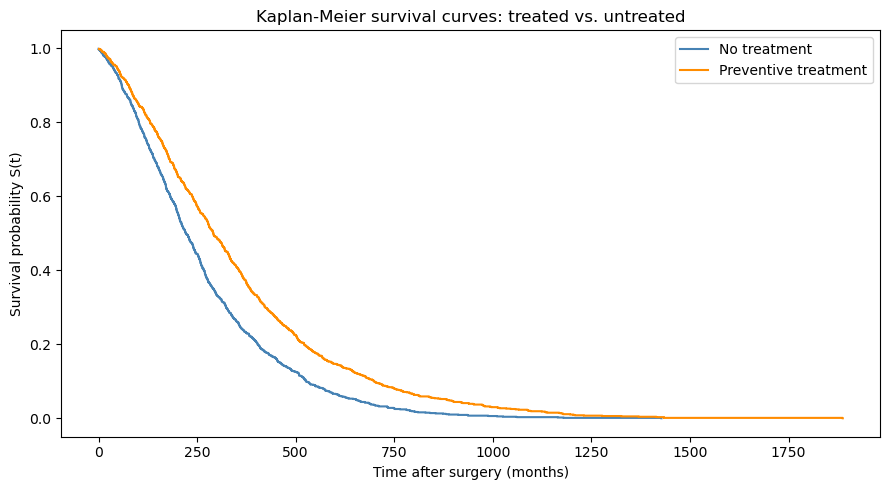

Untreated mean lifetime: 265.9 months
Treated mean lifetime:   349.1 months


In [19]:
# Simulate 1000 treated women
treated_times = []
for _ in range(n):
    t, _ = simulate_woman_ctmc(Q_treatment)
    treated_times.append(t)
treated_times = np.array(treated_times)

def kaplan_meier(lifetimes):
    """
    Kaplan-Meier survival estimate, S(t) = (N - d(t)) / N.
    No censoring here, so this is the step-function empirical survival curve.
    Returns sorted death times and corresponding survival probability just after each death.
    """
    sorted_times = np.sort(lifetimes)
    N = len(sorted_times)
    survival_prob = 1 - np.arange(1, N + 1) / N  # proportion still alive after each death
    return sorted_times, survival_prob

t_untreated, S_untreated = kaplan_meier(death_times)      # from Task 7
t_treated, S_treated     = kaplan_meier(treated_times)

# Plot both survival curves
fig, ax = plt.subplots(figsize=(9, 5))
ax.step(t_untreated, S_untreated, where='post', color='steelblue', label='No treatment')
ax.step(t_treated, S_treated, where='post', color='darkorange', label='Preventive treatment')
ax.set_xlabel('Time after surgery (months)')
ax.set_ylabel('Survival probability S(t)')
ax.set_title('Kaplan-Meier survival curves: treated vs. untreated')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Untreated mean lifetime: {death_times.mean():.1f} months")
print(f"Treated mean lifetime:   {treated_times.mean():.1f} months")

### Task 10

In [20]:
def log_rank_test(times1, times2):
    """
    Log-rank test comparing two survival samples (no censoring).
    times1, times2: arrays of death times for group 1 and group 2.
    Returns chi-square statistic (1 df) and p-value.
    """
    n1, n2 = len(times1), len(times2)

    all_times = np.concatenate([times1, times2])
    group_labels = np.concatenate([np.zeros(n1), np.ones(n2)])  # 0 = group1, 1 = group2

    order = np.argsort(all_times)
    sorted_times = all_times[order]
    sorted_labels = group_labels[order]

    unique_times = np.unique(sorted_times)

    O1_total, E1_total, V_total = 0.0, 0.0, 0.0
    n1_at_risk, n2_at_risk = n1, n2

    for t in unique_times:
        mask = sorted_times == t
        d1 = np.sum((sorted_labels == 0) & mask)  # deaths in group 1 at time t
        d2 = np.sum((sorted_labels == 1) & mask)  # deaths in group 2 at time t
        d = d1 + d2
        n_at_risk = n1_at_risk + n2_at_risk

        if n_at_risk > 1:
            E1 = d * n1_at_risk / n_at_risk
            V = d * (n1_at_risk / n_at_risk) * (n2_at_risk / n_at_risk) * (n_at_risk - d) / (n_at_risk - 1)
        else:
            E1, V = 0.0, 0.0

        O1_total += d1
        E1_total += E1
        V_total += V

        # These women are no longer "at risk" after their death time
        n1_at_risk -= d1
        n2_at_risk -= d2

    chi2_stat = (O1_total - E1_total) ** 2 / V_total
    p_value = 1 - stats.chi2.cdf(chi2_stat, df=1)
    return chi2_stat, p_value

chi2_stat, p_value = log_rank_test(death_times, treated_times)
print(f"Log-rank chi-square statistic: {chi2_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Conclusion: {'Significant difference (reject H0)' if p_value < 0.05 else 'No significant difference (fail to reject H0)'}")

Log-rank chi-square statistic: 66.1618
P-value: 0.000000
Conclusion: Significant difference (reject H0)
